# Weather Data Exploration

This notebook is for exploring and analyzing the collected weather data.

In [15]:
from __future__ import annotations

import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sn
import sys
from dataclasses import dataclass
from pathlib import Path

# --- Jupyter Notebook Safe Path Logic ---
try:
    # Works if running as a normal .py script
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Works if running inside a Jupyter Notebook
    SCRIPT_DIR = Path(os.getcwd()).resolve()

# Check 1 level up and 2 levels up for the project root
PARENT_DIR = SCRIPT_DIR.parent
GRANDPARENT_DIR = SCRIPT_DIR.parent.parent

for path_dir in [SCRIPT_DIR, PARENT_DIR, GRANDPARENT_DIR]:
    if str(path_dir) not in sys.path:
        sys.path.insert(0, str(path_dir))

# --- Target Imports ---
from src.storage import WeatherStorage
from src.parser import WeatherParser


In [16]:
# Load weather data
storage = WeatherStorage()
df = storage.load_from_csv()

if df is not None:
    print(f"Loaded {len(df)} records")
    print(df.head())
    print(f"\nData shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
else:
    print("No data file found. Run main.py first to collect data.")

Loaded 4093 records
             timestamp    location        weather  temperature(C)  \
0  2026-01-29 09:14:42     Bugujju  broken clouds           20.90   
1  2026-01-29 09:14:43       Seeta  broken clouds           22.42   
2  2026-01-29 09:14:43  Namilyango  broken clouds           22.43   
3  2026-01-29 09:14:44     Kyetume  broken clouds           22.15   
4  2026-01-29 09:14:45      Katosi  broken clouds           23.93   

   wind_speed(mps)  humidity(%)  pressure(hPa)  feels_like(C)  visibility(m)  \
0             0.96           74           1015          20.98          10000   
1             1.09           70           1015          22.55          10000   
2             1.20           69           1015          22.53          10000   
3             1.42           57           1016          21.91          10000   
4             2.48           64           1014          24.05          10000   

   clouds(%)  
0         79  
1         77  
2         77  
3         72  
4        

In [17]:
df.weather.unique()  # Check unique weather conditions

<ArrowStringArray>
[   'broken clouds', 'scattered clouds',  'overcast clouds',
       'light rain',    'moderate rain',       'few clouds',
        'clear sky']
Length: 7, dtype: str

In [18]:
# Basic statistics
if df is not None and not df.empty:
    parser = WeatherParser()
    stats = parser.get_summary_stats(df)
    print("Summary Statistics:")
    for key, value in stats.items():
        print(f"{key}: {value}")
    
    print("\n" + "="*50)
    print("\nDataFrame Info:")
    print(df.info())
    print("\n" + "="*50)
    print("\nDescriptive Statistics:")
    print(df.describe())

Summary Statistics:
total_records: 4093
unique_locations: 9
date_range: {'start': '2026-01-29 09:14:42', 'end': '2026-08-05 13:49:33'}
temperature: {'mean': 22.470029318348395, 'min': 15.9, 'max': 33.29}


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 4093 entries, 0 to 4092
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        4093 non-null   str    
 1   location         4093 non-null   str    
 2   weather          4093 non-null   str    
 3   temperature(C)   4093 non-null   float64
 4   wind_speed(mps)  4093 non-null   float64
 5   humidity(%)      4093 non-null   int64  
 6   pressure(hPa)    4093 non-null   int64  
 7   feels_like(C)    4093 non-null   float64
 8   visibility(m)    4093 non-null   int64  
 9   clouds(%)        4093 non-null   int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 479.8 KB
None


Descriptive Statistics:
       temperature(C)  wind_speed(mps) 

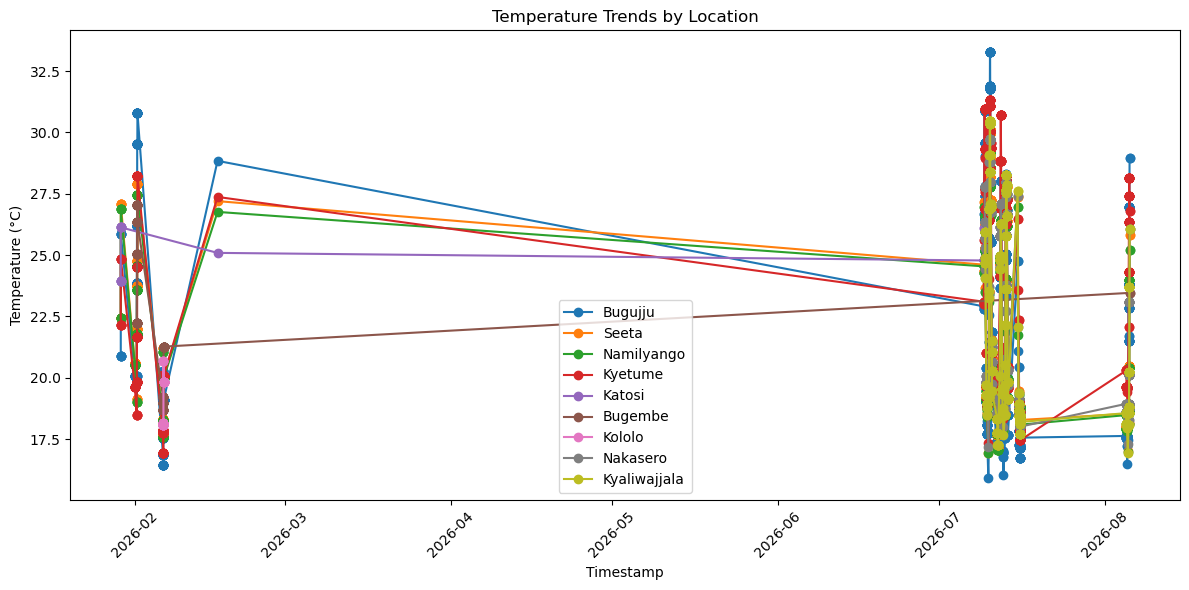

In [19]:
# Visualize temperature trends
if df is not None and not df.empty and 'temperature(C)' in df.columns:
    plt.figure(figsize=(12, 6))
    
    # Convert timestamp to datetime if needed
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')
    
    # Plot temperature by location
    if 'location' in df.columns:
        for location in df['location'].unique():
            location_data = df[df['location'] == location]
            plt.plot(location_data['timestamp'], location_data['temperature(C)'], 
                    label=location, marker='o')
    
    plt.xlabel('Timestamp')
    plt.ylabel('Temperature (°C)')
    plt.title('Temperature Trends by Location')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

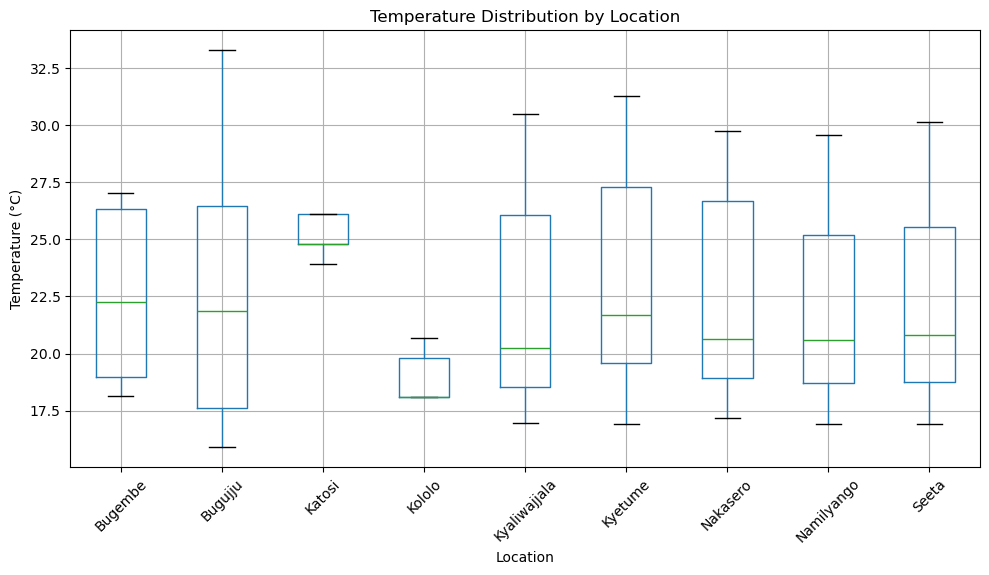

In [20]:
# Temperature distribution by location
if df is not None and not df.empty and 'temperature(C)' in df.columns:
    plt.figure(figsize=(10, 6))
    
    if 'location' in df.columns:
        df.boxplot(column='temperature(C)', by='location', ax=plt.gca())
        plt.title('Temperature Distribution by Location')
        plt.suptitle('')  # Remove default title
        plt.xlabel('Location')
        plt.ylabel('Temperature (°C)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [21]:
# Filter data by location
if df is not None and not df.empty:
    parser = WeatherParser()
    
    # Example: Filter by specific location
    if 'location' in df.columns:
        locations = df['location'].unique()
        print(f"Available locations: {locations}")
        
        # Filter for first location
        if len(locations) > 0:
            filtered_df = parser.filter_by_location(df, locations[0])
            print(f"\nFiltered data for {locations[0]}:")
            print(filtered_df.head())

Available locations: <ArrowStringArray>
[     'Bugujju',        'Seeta',   'Namilyango',      'Kyetume',
       'Katosi',      'Bugembe',       'Kololo',     'Nakasero',
 'Kyaliwajjala']
Length: 9, dtype: str

Filtered data for Bugujju:
             timestamp location        weather  temperature(C)  \
0  2026-01-29 09:14:42  Bugujju  broken clouds            20.9   
5  2026-01-29 09:17:46  Bugujju  broken clouds            20.9   
10 2026-01-29 09:20:50  Bugujju  broken clouds            20.9   
15 2026-01-29 09:23:53  Bugujju  broken clouds            20.9   
20 2026-01-29 09:26:57  Bugujju  broken clouds            20.9   

    wind_speed(mps)  humidity(%)  pressure(hPa)  feels_like(C)  visibility(m)  \
0              0.96           74           1015          20.98          10000   
5              0.96           74           1015          20.98          10000   
10             0.96           74           1015          20.98          10000   
15             0.96           74          